# Naruto-Style SDXL Fine-Tune

**The core question this notebook answers:** can SDXL be fine-tuned to learn the Naruto art
style within a 16GB T4 budget, and what optimizations make that possible? Everything below
is scoped to answer that clearly, not to exhaustively benchmark every possible combination.


In [ ]:
!nvidia-smi

Sun Aug 23 16:11:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q -U pip wheel
!pip install -q "setuptools<82"

!pip install -q -U \
    "diffusers>=0.31.0" \
    "transformers>=4.44,<5.0" \
    "accelerate>=0.34" \
    "peft>=0.13" \
    "bitsandbytes>=0.43" \
    "datasets>=2.21" \
    "safetensors>=0.4.5" \
    "huggingface_hub>=0.24" \
    "DeepCache>=0.1.1" \
    "torchmetrics[image]>=1.4.1" \
    "torchmetrics[multimodal]>=1.4.1" \
    "torchao>=0.16.0" \
    pandas

!pip install -q -U xformers || echo "xformers install failed -- continuing without it."

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [ ]:
import transformers
import torchmetrics
import diffusers

print("transformers:", transformers.__version__)
print("torchmetrics:", torchmetrics.__version__)
print("diffusers:", diffusers.__version__)

transformers: 4.57.6
torchmetrics: 1.9.0
diffusers: 0.39.0


In [ ]:
import transformers
import torchmetrics
import torch

print("Transformers:", transformers.__version__)
print("TorchMetrics:", torchmetrics.__version__)
print("PyTorch:", torch.__version__)

assert int(transformers.__version__.split(".")[0]) < 5, \
    f"Transformers 5.x detected: {transformers.__version__}"

print("✅ Transformers < 5 confirmed")

Transformers: 4.57.6
TorchMetrics: 1.9.0
PyTorch: 2.11.0+cu128
✅ Transformers < 5 confirmed


In [ ]:
import torch
from torchmetrics.multimodal import CLIPScore

metric = CLIPScore(
    model_name_or_path="openai/clip-vit-base-patch32"
)

image = torch.randint(
    0, 256, (3, 224, 224), dtype=torch.uint8
)

try:
    score = metric(image, "a photo of a cat")
    print("✅ CLIPScore works!")
    print("Score:", score)

except Exception as e:
    print("❌ CLIPScore failed:")
    print(type(e).__name__, e)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ CLIPScore works!
Score: tensor(24.3541, grad_fn=<CloneBackward0>)


In [ ]:
!pip install -q "pandas==2.2.3"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
!pip install -q "huggingface-hub==0.36.2"

In [ ]:
import transformers
import huggingface_hub
import torchmetrics

print("Transformers:", transformers.__version__)
print("HuggingFace Hub:", huggingface_hub.__version__)
print("TorchMetrics:", torchmetrics.__version__)

Transformers: 4.57.6
HuggingFace Hub: 0.36.2
TorchMetrics: 1.9.0


In [ ]:
import os, gc, time, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from datasets import load_dataset
from diffusers import (AutoencoderKL, UNet2DConditionModel, DDPMScheduler,
                        StableDiffusionXLPipeline, EulerDiscreteScheduler)
from diffusers.models.attention_processor import AttnProcessor2_0
from transformers import CLIPTextModel, CLIPTextModelWithProjection, CLIPTokenizer
from peft import LoraConfig, get_peft_model_state_dict
import bitsandbytes as bnb
from diffusers.optimization import get_scheduler
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.multimodal.clip_score import CLIPScore

try:
    from diffusers import BitsAndBytesConfig
except ImportError:
    from transformers import BitsAndBytesConfig

device = "cuda" if torch.cuda.is_available() else "cpu"
assert device == "cuda", "Run this on a Colab GPU runtime."
weight_dtype = torch.float16
print("device:", device, "|", torch.cuda.get_device_name(0))

def slug(name):
    return name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "").replace(",", "")


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device: cuda | Tesla T4


## Config

In [ ]:
class CFG:
    base_model_id = "stabilityai/stable-diffusion-xl-base-1.0"
    vae_id        = "madebyollin/sdxl-vae-fp16-fix"
    dataset_id    = "lambdalabs/naruto-blip-captions"

    resolution = 1024   
    val_fraction = 0.15

    train_batch_size            = 1
    gradient_accumulation_steps = 8   
    n_screen_steps       = 100
    screen_subset_size   = 200
    screen_eval_every     = 20


    n_full_steps      = 600
    full_eval_every    = 50

    lr_warmup_steps = 20
    seed = 42
    screen_output_root = "screening_runs"
    full_output_root    = "full_runs"

cfg = CFG()
torch.manual_seed(cfg.seed); random.seed(cfg.seed)
os.makedirs(cfg.screen_output_root, exist_ok=True)
os.makedirs(cfg.full_output_root, exist_ok=True)

TARGET_MODULES = ["to_q", "to_k", "to_v", "to_out.0"]

TEST_PROMPTS = [
    "Naruto Uzumaki eating ramen",
    "Bill Gates in Naruto style",
    "A boy with blue eyes in Naruto style",
]


## 1. Cache the dataset first and free memory afterwards

The VAE and both text encoders are frozen, so we use them only once on the full dataset. We save the results and use the same cache for both screening and full training. This means we do not need to process the dataset twice.

After this step, we remove the VAE and text encoders to free up GPU memory. From this point, each training run only loads the UNet.


In [ ]:
tokenizer_one = CLIPTokenizer.from_pretrained(cfg.base_model_id, subfolder="tokenizer")
tokenizer_two = CLIPTokenizer.from_pretrained(cfg.base_model_id, subfolder="tokenizer_2")
text_encoder_one = CLIPTextModel.from_pretrained(cfg.base_model_id, subfolder="text_encoder", torch_dtype=weight_dtype).to(device)
text_encoder_two = CLIPTextModelWithProjection.from_pretrained(cfg.base_model_id, subfolder="text_encoder_2", torch_dtype=weight_dtype).to(device)
vae = AutoencoderKL.from_pretrained(cfg.vae_id, torch_dtype=torch.float32).to(device)
vae.enable_tiling()  # safety margin while encoding at 1024 -- cheap insurance
for m in (text_encoder_one, text_encoder_two, vae):
    m.requires_grad_(False)
    m.eval()

train_transforms = transforms.Compose([
    transforms.Resize(cfg.resolution, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(cfg.resolution),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

@torch.no_grad()
def encode_prompt(caption):
    embeds_list, pooled = [], None
    for tok, enc in [(tokenizer_one, text_encoder_one), (tokenizer_two, text_encoder_two)]:
        ti = tok(caption, padding="max_length", max_length=tok.model_max_length, truncation=True, return_tensors="pt").to(device)
        out = enc(ti.input_ids, output_hidden_states=True)
        embeds_list.append(out.hidden_states[-2])
        if enc is text_encoder_two:
            pooled = out[0]
    return torch.cat(embeds_list, dim=-1).squeeze(0).cpu(), pooled.squeeze(0).cpu()

@torch.no_grad()
def encode_image(image):
    pv = train_transforms(image.convert("RGB")).unsqueeze(0).to(device, dtype=torch.float32)
    return (vae.encode(pv).latent_dist.sample() * vae.config.scaling_factor).squeeze(0).cpu()

full_dataset = load_dataset(cfg.dataset_id, split="train")
split = full_dataset.train_test_split(test_size=cfg.val_fraction, seed=cfg.seed)
train_examples, val_examples = split["train"], split["test"]
print(f"{len(train_examples)} train examples, {len(val_examples)} held-out validation examples "
      f"({cfg.val_fraction:.0%}) -- held out for both loss-based validation and later FID.")

def build_cache(examples, label):
    cached = []
    for i, ex in enumerate(examples):
        latents = encode_image(ex["image"])
        pe, pooled = encode_prompt(ex["text"])
        cached.append({"latents": latents, "prompt_embeds": pe, "pooled_embeds": pooled})
        if (i + 1) % 200 == 0:
            print(f"  cached {i+1}/{len(examples)} {label} examples...")
    print(f"Cached {len(cached)} {label} examples.")
    return cached

train_cache = build_cache(train_examples, "train")
val_cache   = build_cache(val_examples, "validation")

del vae, text_encoder_one, text_encoder_two
gc.collect(); torch.cuda.empty_cache()
print("VAE + text encoders freed from VRAM.")


`torch_dtype` is deprecated! Use `dtype` instead!
Repo card metadata block was not found. Setting CardData to empty.


1037 train examples, 184 held-out validation examples (15%) -- held out for both loss-based validation and later FID.
  cached 200/1037 train examples...
  cached 400/1037 train examples...
  cached 600/1037 train examples...
  cached 800/1037 train examples...
  cached 1000/1037 train examples...
Cached 1037 train examples.
Cached 184 validation examples.
VAE + text encoders freed from VRAM.


In [ ]:
class CachedLatentsDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

def collate_fn(examples):
    return {
        "latents": torch.stack([e["latents"] for e in examples]),
        "prompt_embeds": torch.stack([e["prompt_embeds"] for e in examples]),
        "pooled_embeds": torch.stack([e["pooled_embeds"] for e in examples]),
    }

def make_dataloader(cached_list, shuffle):
    return DataLoader(CachedLatentsDataset(cached_list), batch_size=cfg.train_batch_size,
                       shuffle=shuffle, collate_fn=collate_fn)

screen_train_dataloader = make_dataloader(train_cache[:cfg.screen_subset_size], shuffle=True)
full_train_dataloader   = make_dataloader(train_cache, shuffle=True)
val_dataloader          = make_dataloader(val_cache, shuffle=False)

def cycle(dl):
    while True:
        for b in dl:
            yield b

noise_scheduler = DDPMScheduler.from_pretrained(cfg.base_model_id, subfolder="scheduler")

def get_add_time_ids(res, dtype, bsz):
    return torch.tensor([[res, res, 0, 0, res, res]], dtype=dtype).repeat(bsz, 1).to(device)


scheduler_config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

## 2. UNet loader (fp16 or 4-bit QLoRA) + validation-loss helper

In [ ]:
def load_unet(adapter_type):
    if adapter_type == "qlora":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=weight_dtype, bnb_4bit_use_double_quant=True,
        )
        unet = UNet2DConditionModel.from_pretrained(
            cfg.base_model_id, subfolder="unet",
            quantization_config=bnb_config, torch_dtype=weight_dtype, device_map={"": 0},
        )
    else:
        unet = UNet2DConditionModel.from_pretrained(
            cfg.base_model_id, subfolder="unet", torch_dtype=weight_dtype,
        ).to(device)
    unet.requires_grad_(False)
    return unet


@torch.no_grad()
def compute_validation_loss(unet):
    unet.eval()
    losses = []
    for batch in val_dataloader:
        latents = batch["latents"].to(device, dtype=torch.float32)
        prompt_embeds = batch["prompt_embeds"].to(device, dtype=weight_dtype)
        pooled_embeds = batch["pooled_embeds"].to(device, dtype=weight_dtype)
        bsz = latents.shape[0]
        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps).to(weight_dtype)
        add_time_ids = get_add_time_ids(cfg.resolution, weight_dtype, bsz)
        added_cond_kwargs = {"text_embeds": pooled_embeds, "time_ids": add_time_ids}
        with torch.cuda.amp.autocast():
            pred = unet(noisy_latents, timesteps, encoder_hidden_states=prompt_embeds,
                        added_cond_kwargs=added_cond_kwargs).sample
            loss = F.mse_loss(pred.float(), noise.float())
        losses.append(loss.item())
    unet.train()
    return sum(losses) / len(losses)


## 3. Generic train function (used for both screening and full training)

In [ ]:
def train_config(run_cfg, dataloader, n_steps, eval_every, output_root):
    print(f"\n=== {run_cfg['name']} ({n_steps} steps) ===")
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

    unet = load_unet(run_cfg["adapter"])
    lora_config = LoraConfig(
        r=run_cfg["rank"], lora_alpha=run_cfg["alpha"], lora_dropout=0.0,
        target_modules=TARGET_MODULES, use_dora=run_cfg["use_dora"],
    )
    unet.add_adapter(lora_config)
    for n, p in unet.named_parameters():
        if "lora" in n:
            p.data = p.data.to(torch.float32)
            p.requires_grad_(True)

    trainable_params = [p for p in unet.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable_params)

    unet.enable_gradient_checkpointing()
    unet.enable_xformers_memory_efficient_attention()

    optimizer = bnb.optim.AdamW8bit(trainable_params, lr=run_cfg["lr"], weight_decay=1e-2)
    lr_scheduler = get_scheduler("constant_with_warmup", optimizer=optimizer,
                                  num_warmup_steps=min(cfg.lr_warmup_steps, n_steps // 4),
                                  num_training_steps=n_steps)
    scaler = torch.cuda.amp.GradScaler()

    unet.train()
    train_losses, val_steps, val_losses = [], [], []
    data_iter = cycle(dataloader)
    t0 = time.time()

    for step in range(n_steps):
        batch = next(data_iter)
        latents = batch["latents"].to(device, dtype=torch.float32)
        prompt_embeds = batch["prompt_embeds"].to(device, dtype=weight_dtype)
        pooled_embeds = batch["pooled_embeds"].to(device, dtype=weight_dtype)
        bsz = latents.shape[0]

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps).to(weight_dtype)
        add_time_ids = get_add_time_ids(cfg.resolution, weight_dtype, bsz)
        added_cond_kwargs = {"text_embeds": pooled_embeds, "time_ids": add_time_ids}

        with torch.cuda.amp.autocast():
            pred = unet(noisy_latents, timesteps, encoder_hidden_states=prompt_embeds,
                        added_cond_kwargs=added_cond_kwargs).sample
            loss = F.mse_loss(pred.float(), noise.float())
            loss_scaled = loss / cfg.gradient_accumulation_steps

        scaler.scale(loss_scaled).backward()
        if (step + 1) % cfg.gradient_accumulation_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
            scaler.step(optimizer); scaler.update()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        train_losses.append(loss.item())

        if (step + 1) % eval_every == 0 or step == n_steps - 1:
            val_loss = compute_validation_loss(unet)
            val_steps.append(step + 1)
            val_losses.append(val_loss)
            print(f"  step {step+1}/{n_steps} | train {loss.item():.4f} | val {val_loss:.4f}")

    elapsed = time.time() - t0
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

    save_path = os.path.join(output_root, slug(run_cfg["name"]))
    os.makedirs(save_path, exist_ok=True)
    state_dict = get_peft_model_state_dict(unet)
    StableDiffusionXLPipeline.save_lora_weights(save_path, unet_lora_layers=state_dict)

    result = dict(
        name=run_cfg["name"], adapter=run_cfg["adapter"], rank=run_cfg["rank"], alpha=run_cfg["alpha"],
        lr=run_cfg["lr"], n_trainable=n_trainable, peak_mem_gb=peak_mem_gb, elapsed_s=elapsed,
        train_losses=train_losses, val_steps=val_steps, val_losses=val_losses,
        final_train_loss=sum(train_losses[-min(20, len(train_losses)):]) / min(20, len(train_losses)),
        final_val_loss=val_losses[-1], save_path=save_path,
    )
    print(f"  done: {n_trainable:,} params | peak {peak_mem_gb:.2f}GB | {elapsed:.0f}s | "
          f"final train {result['final_train_loss']:.4f} | final val {result['final_val_loss']:.4f}")

    del unet, optimizer
    gc.collect(); torch.cuda.empty_cache()
    return result


---
## STAGE 1: Screening — LoRA / DoRA / QLoRA, 2 configs each

Short runs on a small subset, at the real target resolution, to cheaply eliminate weak
hyperparameter choices before committing full-dataset training time to them.

In [ ]:
SCREEN_CONFIGS = [
    dict(name="LoRA A (r=8, α=16)",   adapter="lora",  rank=8,  alpha=16, lr=1e-4, use_dora=False),
    dict(name="LoRA B (r=16, α=32)",  adapter="lora",  rank=16, alpha=32, lr=1e-4, use_dora=False),
    dict(name="DoRA A (r=8, α=16)",   adapter="dora",  rank=8,  alpha=16, lr=1e-4, use_dora=True),
    dict(name="DoRA B (r=16, α=32)",  adapter="dora",  rank=16, alpha=32, lr=1e-4, use_dora=True),
    dict(name="QLoRA A (r=8, α=16)",  adapter="qlora", rank=8,  alpha=16, lr=1e-4, use_dora=False),
    dict(name="QLoRA B (r=16, α=32)", adapter="qlora", rank=16, alpha=32, lr=1e-4, use_dora=False),
]

screening_results = []
for sc in SCREEN_CONFIGS:
    try:
        screening_results.append(train_config(
            sc, screen_train_dataloader, cfg.n_screen_steps, cfg.screen_eval_every, cfg.screen_output_root
        ))
    except Exception as e:
        print(f"  FAILED ({sc['name']}): {e}")
        gc.collect(); torch.cuda.empty_cache()

screening_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("train_losses", "val_steps", "val_losses")}
    for r in screening_results
])
screening_df



=== LoRA A (r=8, α=16) (100 steps) ===


/tmp/ipykernel_837/3573059665.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_837/3573059665.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_837/986217795.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  step 20/100 | train 0.0391 | val 0.0802
  step 40/100 | train 0.2068 | val 0.0813
  step 60/100 | train 0.0113 | val 0.0917
  step 80/100 | train 0.0063 | val 0.0870
  step 100/100 | train 0.1564 | val 0.0894
  done: 11,612,160 params | peak 6.44GB | 660s | final train 0.1026 | final val 0.0894

=== LoRA B (r=16, α=32) (100 steps) ===
  step 20/100 | train 0.0614 | val 0.0937
  step 40/100 | train 0.2767 | val 0.0899
  step 60/100 | train 0.2106 | val 0.0942
  step 80/100 | train 0.0782 | val 0.0860
  step 100/100 | train 0.2717 | val 0.0874
  done: 23,224,320 params | peak 6.56GB | 663s | final train 0.1029 | final val 0.0874

=== DoRA A (r=8, α=16) (100 steps) ===
  step 20/100 | train 0.0512 | val 0.0844
  step 40/100 | train 0.0614 | val 0.0840
  step 60/100 | train 0.0166 | val 0.0800
  step 80/100 | train 0.0189 | val 0.0766
  step 100/100 | train 0.2488 | val 0.0903
  done: 12,277,760 params | peak 6.45GB | 1103s | final train 0.0467 | final val 0.0903

=== DoRA B (r=16, α=32)

,name,adapter,rank,alpha,lr,n_trainable,peak_mem_gb,elapsed_s,final_train_loss,final_val_loss,save_path
0,"LoRA A (r=8, α=16)",lora,8,16,0.0001,11612160,6.441366,660.305255,0.102591,0.089432,screening_runs/LoRA_A_r8_α16
1,"LoRA B (r=16, α=32)",lora,16,32,0.0001,23224320,6.557357,663.161847,0.102944,0.087384,screening_runs/LoRA_B_r16_α32
2,"DoRA A (r=8, α=16)",dora,8,16,0.0001,12277760,6.451885,1103.290704,0.046747,0.090279,screening_runs/DoRA_A_r8_α16
3,"DoRA B (r=16, α=32)",dora,16,32,0.0001,23889920,6.568006,1103.872842,0.122621,0.086830,screening_runs/DoRA_B_r16_α32


### Select the best config per adapter type -> 3 winners proceed to full training

In [ ]:
winners = []
for adapter_type in ["lora", "dora", "qlora"]:
    sub = screening_df[screening_df["adapter"] == adapter_type]
    if len(sub) == 0:
        continue
    best_name = sub.loc[sub["final_val_loss"].idxmin(), "name"]
    winners.append(next(sc for sc in SCREEN_CONFIGS if sc["name"] == best_name))
    print(f"{adapter_type.upper()} winner: {best_name} (val loss {sub['final_val_loss'].min():.4f})")

print(f"\nProceeding to full training with: {[w['name'] for w in winners]}")


LORA winner: LoRA B (r=16, α=32) (val loss 0.0874)
DORA winner: DoRA B (r=16, α=32) (val loss 0.0868)

Proceeding to full training with: ['LoRA B (r=16, α=32)', 'DoRA B (r=16, α=32)']


---
## STAGE 2: Full training — the 3 winners, on the full dataset

In [ ]:
full_results = []
for wc in winners:
    try:
        full_results.append(train_config(
            wc, full_train_dataloader, cfg.n_full_steps, cfg.full_eval_every, cfg.full_output_root
        ))
    except Exception as e:
        print(f"  FAILED ({wc['name']}): {e}")
        gc.collect(); torch.cuda.empty_cache()

full_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("train_losses", "val_steps", "val_losses")}
    for r in full_results
])
full_df



=== LoRA B (r=16, α=32) (600 steps) ===


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/tmp/ipykernel_837/3573059665.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_837/3573059665.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_837/986217795.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  step 50/600 | train 0.2625 | val 0.0783
  step 100/600 | train 0.0053 | val 0.0933
  step 150/600 | train 0.1187 | val 0.0827
  step 200/600 | train 0.0299 | val 0.0849
  step 250/600 | train 0.0547 | val 0.0909
  step 300/600 | train 0.0385 | val 0.0799
  step 350/600 | train 0.0305 | val 0.0914
  step 400/600 | train 0.0565 | val 0.0865
  step 450/600 | train 0.2120 | val 0.0814
  step 500/600 | train 0.0881 | val 0.0896
  step 550/600 | train 0.0543 | val 0.0891
  step 600/600 | train 0.2182 | val 0.0878
  done: 23,224,320 params | peak 6.56GB | 2233s | final train 0.0870 | final val 0.0878

=== DoRA B (r=16, α=32) (600 steps) ===
  step 50/600 | train 0.1227 | val 0.0940
  step 100/600 | train 0.0243 | val 0.0875
  step 150/600 | train 0.2624 | val 0.0905
  step 200/600 | train 0.2012 | val 0.0934
  step 250/600 | train 0.0213 | val 0.0925
  step 300/600 | train 0.0787 | val 0.0771
  step 350/600 | train 0.1074 | val 0.0942
  step 400/600 | train 0.2628 | val 0.0900
  step 450/60

,name,adapter,rank,alpha,lr,n_trainable,peak_mem_gb,elapsed_s,final_train_loss,final_val_loss,save_path
0,"LoRA B (r=16, α=32)",lora,16,32,0.0001,23224320,6.557358,2232.673332,0.086974,0.087770,full_runs/LoRA_B_r16_α32
1,"DoRA B (r=16, α=32)",dora,16,32,0.0001,23889920,6.568007,3659.430697,0.116982,0.078562,full_runs/DoRA_B_r16_α32


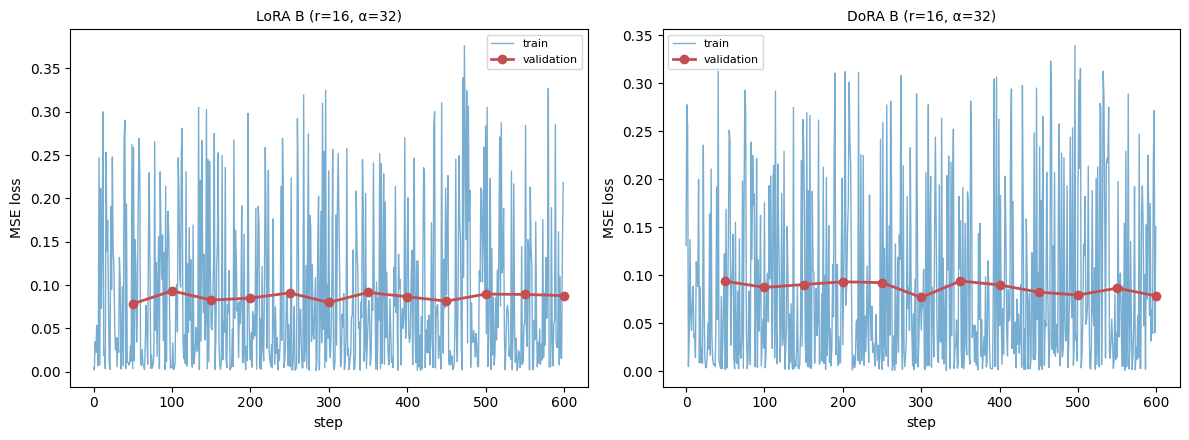

In [ ]:
fig, axes = plt.subplots(1, len(full_results), figsize=(6 * len(full_results), 4.5))
if len(full_results) == 1:
    axes = [axes]
for ax, r in zip(axes, full_results):
    ax.plot(r["train_losses"], label="train", alpha=0.6, linewidth=1)
    ax.plot(r["val_steps"], r["val_losses"], label="validation", marker="o", linewidth=2, color="#C44E52")
    ax.set_title(r["name"], fontsize=10)
    ax.set_xlabel("step"); ax.set_ylabel("MSE loss"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("full_training_curves.png", dpi=140, bbox_inches="tight"); plt.show()


### Pick the single best checkpoint by validation loss

(Visual/qualitative confirmation happens in the Evaluation stage below.)

In [ ]:
best_row = full_df.loc[full_df["final_val_loss"].idxmin()]
best_lora_path = best_row["save_path"]
print(f"Best checkpoint: {best_row['name']} (val loss {best_row['final_val_loss']:.4f})")
print(f"Weights: {best_lora_path}")

# Free the caching/dataset objects we no longer need -- keep val_examples (lightweight,
# lazily-loaded HF Dataset) around for FID reference images later.
del train_cache
gc.collect(); torch.cuda.empty_cache()


Best checkpoint: DoRA B (r=16, α=32) (val loss 0.0786)
Weights: full_runs/DoRA_B_r16_α32


In [ ]:
import shutil
shutil.unpack_archive("/content/screening_runs.zip", "/content/")

In [ ]:
import shutil
shutil.unpack_archive("/content/full_runs.zip", "/content/")

In [ ]:
best_lora_path = "full_runs/DoRA_B_r16_α32"

---
## STAGE 3: Inference optimization (on the single best checkpoint only)


In [ ]:
def reset_memory_stats():
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

def benchmark_pipe(pipe, label, prompt=TEST_PROMPTS[0], steps=25, guidance=7.0, seed=cfg.seed, n_runs=2):
    reset_memory_stats()
    gen = torch.Generator(device=device).manual_seed(seed)
    _ = pipe(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=gen).images[0]  # warmup
    reset_memory_stats()
    times = []
    for _ in range(n_runs):
        gen = torch.Generator(device=device).manual_seed(seed)
        torch.cuda.synchronize(); t0 = time.time()
        image = pipe(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=gen).images[0]
        torch.cuda.synchronize()
        times.append(time.time() - t0)
    result = dict(label=label, avg_latency_s=sum(times) / len(times),
                  images_per_sec=1.0 / (sum(times) / len(times)),
                  peak_mem_gb=torch.cuda.max_memory_allocated() / 1e9, image=image)
    print(f"[{label}] {result['avg_latency_s']:.2f}s/image | {result['images_per_sec']:.3f} img/s | "
          f"peak {result['peak_mem_gb']:.2f}GB")
    return result

inference_results = []


In [ ]:
# 1. Baseline (default SDPA)
pipe = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
pipe.load_lora_weights(best_lora_path)
pipe.set_progress_bar_config(disable=True)
inference_results.append(benchmark_pipe(pipe, "Baseline (SDPA)"))


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. Fo

[Baseline (SDPA)] 28.36s/image | 0.035 img/s | peak 10.84GB


In [ ]:
# 2. VAE tiling + slicing
pipe.vae.enable_tiling(); pipe.vae.enable_slicing()
inference_results.append(benchmark_pipe(pipe, "VAE tiling + slicing"))
pipe.vae.disable_tiling(); pipe.vae.disable_slicing()

del pipe
reset_memory_stats()


There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results

[VAE tiling + slicing] 29.60s/image | 0.034 img/s | peak 10.85GB


In [ ]:
# 3. Model CPU offload (fresh pipeline -- offload is set up before first use)
pipe_offload = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
)
pipe_offload.load_lora_weights(best_lora_path)
pipe_offload.enable_model_cpu_offload()
pipe_offload.set_progress_bar_config(disable=True)
inference_results.append(benchmark_pipe(pipe_offload, "Model CPU offload"))
del pipe_offload
reset_memory_stats()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be k

[Model CPU offload] 34.58s/image | 0.029 img/s | peak 5.98GB


In [ ]:
# 4. DeepCache
from DeepCache import DeepCacheSDHelper

pipe = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
pipe.load_lora_weights(best_lora_path)
pipe.set_progress_bar_config(disable=True)

helper = DeepCacheSDHelper(pipe=pipe)
helper.set_params(cache_interval=3, cache_branch_id=0)
helper.enable()
inference_results.append(benchmark_pipe(pipe, "DeepCache"))
helper.disable()


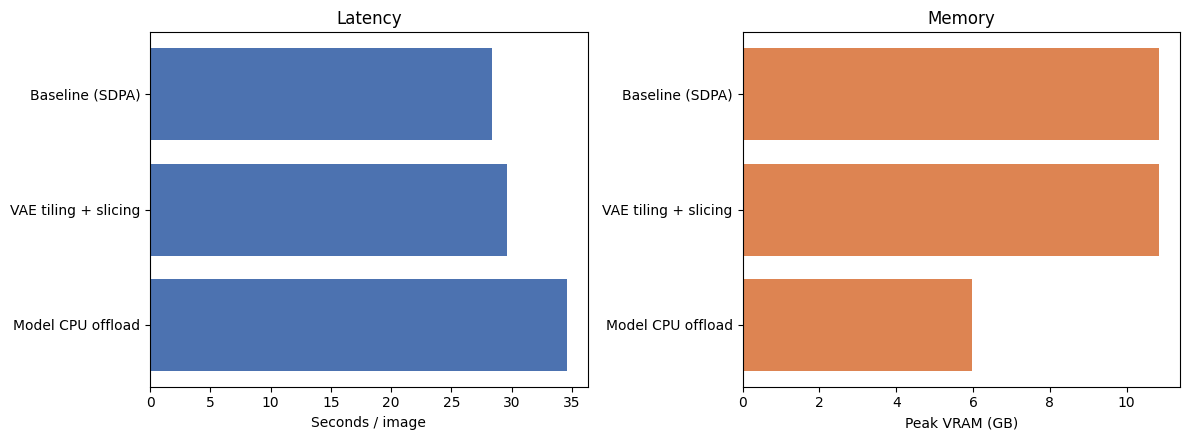

,label,avg_latency_s,images_per_sec,peak_mem_gb
0,Baseline (SDPA),28.355056,0.035267,10.842052
1,VAE tiling + slicing,29.600231,0.033784,10.845197
2,Model CPU offload,34.575617,0.028922,5.976901


In [ ]:
inf_df = pd.DataFrame([{k: v for k, v in r.items() if k != "image"} for r in inference_results])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(inf_df["label"], inf_df["avg_latency_s"], color="#4C72B0")
axes[0].set_xlabel("Seconds / image"); axes[0].set_title("Latency"); axes[0].invert_yaxis()
axes[1].barh(inf_df["label"], inf_df["peak_mem_gb"], color="#DD8452")
axes[1].set_xlabel("Peak VRAM (GB)"); axes[1].set_title("Memory"); axes[1].invert_yaxis()
plt.tight_layout(); plt.savefig("inference_optimization_results.png", dpi=140, bbox_inches="tight"); plt.show()

inf_df


---
## STAGE 4: Evaluation (compare the base model and fine-tuned model)

We compare the base SDXL model with our best fine-tuned model using the same 3 test prompts and the same seeds. We use the fastest inference setting that does not make the results worse, if we found one. Otherwise, we use the normal setting.

For the numbers, we use **CLIP** to check how well the images follow the prompts and **FID** to check how similar the style is to the real Naruto images from the 15% test set.


Using 'Baseline (SDPA)' config for the fine-tuned side of the comparison (fastest measured above).


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be k

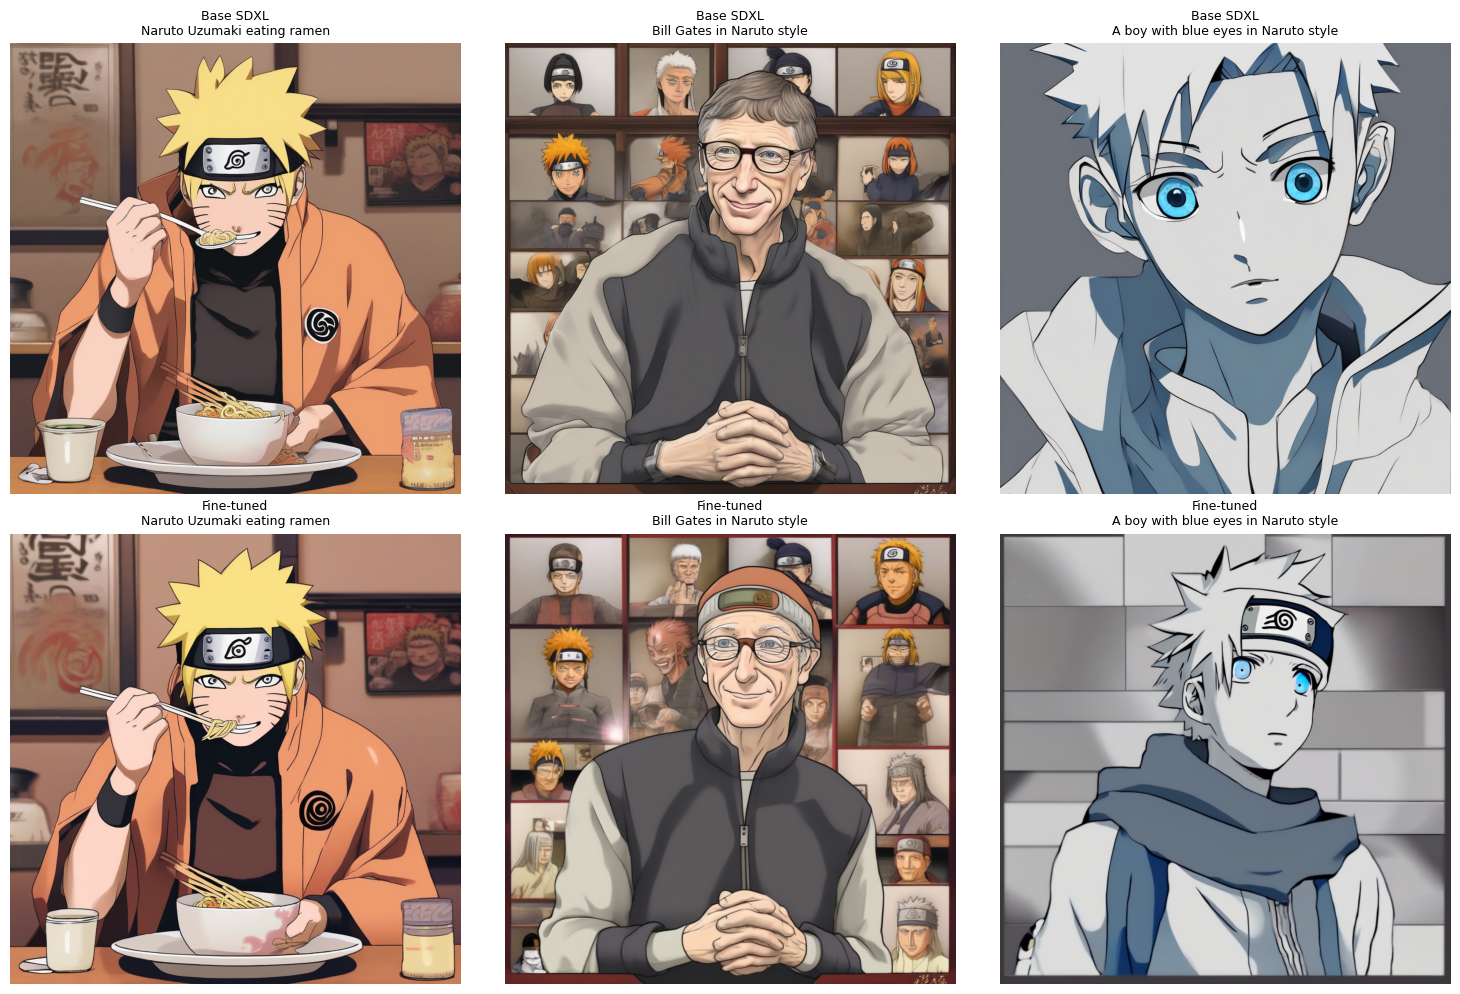

In [ ]:
best_inference_label = inf_df.loc[inf_df["avg_latency_s"].idxmin(), "label"]
print(f"Using '{best_inference_label}' config for the fine-tuned side of the comparison "
      f"(fastest measured above).")

base_pipe = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
base_pipe.set_progress_bar_config(disable=True)

base_qual_images = []
for prompt in TEST_PROMPTS:
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    base_qual_images.append(base_pipe(prompt, num_inference_steps=25, guidance_scale=7.0, generator=gen).images[0])
del base_pipe
reset_memory_stats()

ft_pipe = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
ft_pipe.load_lora_weights(best_lora_path)
ft_pipe.set_progress_bar_config(disable=True)

ft_qual_images = []
for prompt in TEST_PROMPTS:
    gen = torch.Generator(device=device).manual_seed(cfg.seed)
    ft_qual_images.append(ft_pipe(prompt, num_inference_steps=25, guidance_scale=7.0, generator=gen).images[0])

fig, axes = plt.subplots(2, len(TEST_PROMPTS), figsize=(5 * len(TEST_PROMPTS), 10))
for i, prompt in enumerate(TEST_PROMPTS):
    axes[0, i].imshow(base_qual_images[i]); axes[0, i].set_title(f"Base SDXL\n{prompt}", fontsize=9); axes[0, i].axis("off")
    axes[1, i].imshow(ft_qual_images[i]); axes[1, i].set_title(f"Fine-tuned\n{prompt}", fontsize=9); axes[1, i].axis("off")
plt.tight_layout(); plt.savefig("base_vs_finetuned_qualitative.png", dpi=140, bbox_inches="tight"); plt.show()


### Quantitative: CLIP score + FID, base vs. fine-tuned, on held-out captions

In [ ]:
N_QUANT_SAMPLES = min(15, len(val_examples))
quant_examples = val_examples.select(range(N_QUANT_SAMPLES))
quant_prompts = [ex["text"] for ex in quant_examples]
real_images_299 = [ex["image"].convert("RGB").resize((299, 299)) for ex in quant_examples]

def pil_to_uint8_tensor(images_pil, size=299):
    arrs = [np.array(img.resize((size, size))) for img in images_pil]
    return torch.from_numpy(np.stack(arrs)).permute(0, 3, 1, 2).to(device)

real_tensor = pil_to_uint8_tensor(real_images_299)

clip_metric = CLIPScore(model_name_or_path="openai/clip-vit-base-patch16").to(device)

def score_pipe(pipe, label):
    imgs = []
    for i, prompt in enumerate(quant_prompts):
        gen = torch.Generator(device=device).manual_seed(cfg.seed + i)
        imgs.append(pipe(prompt, num_inference_steps=25, guidance_scale=7.0, generator=gen).images[0])
    gen_tensor = pil_to_uint8_tensor(imgs)

    clip_score = clip_metric(gen_tensor, quant_prompts).item()

    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    fid.update(real_tensor.float() / 255.0, real=True)
    fid.update(gen_tensor.float() / 255.0, real=False)
    fid_score = fid.compute().item()
    del fid

    print(f"{label}: CLIP {clip_score:.3f} | FID {fid_score:.2f}")
    return dict(label=label, clip_score=clip_score, fid=fid_score)

quant_results = [score_pipe(ft_pipe, "Fine-tuned (this checkpoint)")]

del ft_pipe
reset_memory_stats()

base_pipe = StableDiffusionXLPipeline.from_pretrained(
    cfg.base_model_id, torch_dtype=torch.float16, variant="fp16", use_safetensors=True,
).to(device)
base_pipe.set_progress_bar_config(disable=True)
quant_results.append(score_pipe(base_pipe, "Base SDXL (no fine-tune)"))
del base_pipe
reset_memory_stats()

quant_df = pd.DataFrame(quant_results)
quant_df


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

...

Fine-tuned (this checkpoint): CLIP 30.934 | FID 283.30


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results

Base SDXL (no fine-tune): CLIP 31.368 | FID 346.97


,label,clip_score,fid
0,Fine-tuned (this checkpoint),30.933590,283.303345
1,Base SDXL (no fine-tune),31.368441,346.970642
